
<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Naive Bayes Classifier </h2>
</div>

* It’s a classification technique based on Bayes Theorem with a assumption of indepedendence among predictors
* All input variable are independent and all are classified data
* When more than 2 classes to predict, then we go with Linear Regression or Decision Tree, or Randome Forest or Naivey Bayes Classification. For 2 classs we can use Logistic Regression.
* This is used to identify the inverted probability, means, "if one occurse, then probability of occurance of another"

* Naïve Bayes Classifier is one of the simple and most effective Classification algorithms which helps in building the fast machine learning models that can make quick predictions. 
* It is a probabilistic classifier, which means it predicts on the basis of the probability of an object


##### Types of Naïve Bayes Algorithm:		
		
	1.Gaussian Algorithm	
		Continous / Real valued features
		Its used in classification and it assumes that feature followes a normal distribution
		
	2.Multinomial	
		Discrete feature. This used for discrete counts ex,text classification problem, word counts etc
		
	3.Bernoulli	
		Binary Features(Word presence/absence)
		


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>


## PACIFIC HURRICANE

> The NHC publishes the tropical cyclone historical database in a format known as HURDAT, short for HURricane DATabase. These databases (Atlantic HURDAT2 and NE/NC Pacific HURDAT2) contain six-hourly information on the location, maximum winds, central pressure, and (starting in 2004) size of all known tropical cyclones and subtropical cyclones.


> Here STATUS is output column, based on other feature we need to decide which is the best model to predict Hurricane status

> Its categorial o/p not continous one. So its not a regression problem. Its a classification problem with more than 2 value to predict. So we use Supervised Classification Models like 

> Logistic Regression 

> Decision Tree ( we did same example for Naive bayes in other folder)

> Random Forest

> Naive bayes  

##  1. Import all Librariy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [2]:
## load the data
data = pd.read_csv(r"../Dataset/pacific.csv")
data.head()

,ID,Name,Date,Time,Event,Status,Latitude,Longitude,Maximum Wind,Minimum Pressure,...,Low Wind SW,Low Wind NW,Moderate Wind NE,Moderate Wind SE,Moderate Wind SW,Moderate Wind NW,High Wind NE,High Wind SE,High Wind SW,High Wind NW
0,EP011949,UNNAMED,19490611,0,,TS,20.2N,106.3W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
1,EP011949,UNNAMED,19490611,600,,TS,20.2N,106.4W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
2,EP011949,UNNAMED,19490611,1200,,TS,20.2N,106.7W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
3,EP011949,UNNAMED,19490611,1800,,TS,20.3N,107.7W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
4,EP011949,UNNAMED,19490612,0,,TS,20.4N,108.6W,45,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999


## 2. Data Exploration with Graphs and Visualization

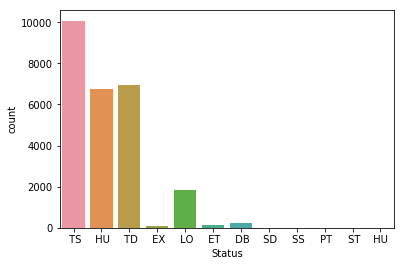

In [3]:
sns.countplot(data['Status'])
plt.show()

In [4]:
# data  wrangling
# data  wrangling, Remove unnecessary column
pred_columns = data[:]
pred_columns.drop(['ID','Name','Event','Status','Latitude','Longitude'],
                 inplace=True,
                 axis=1)
pred_columns.head()


C:\Users\prabh\Anaconda3\lib\site-packages\pandas\core\frame.py:3697: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  errors=errors)


,Date,Time,Maximum Wind,Minimum Pressure,Low Wind NE,Low Wind SE,Low Wind SW,Low Wind NW,Moderate Wind NE,Moderate Wind SE,Moderate Wind SW,Moderate Wind NW,High Wind NE,High Wind SE,High Wind SW,High Wind NW
0,19490611,0,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
1,19490611,600,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
2,19490611,1200,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
3,19490611,1800,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999
4,19490612,0,45,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999,-999


In [5]:
# store the relevant columns
relevant_columns = pred_columns.columns
print(list(relevant_columns))

['Date', 'Time', 'Maximum Wind', 'Minimum Pressure', 'Low Wind NE', 'Low Wind SE', 'Low Wind SW', 'Low Wind NW', 'Moderate Wind NE', 'Moderate Wind SE', 'Moderate Wind SW', 'Moderate Wind NW', 'High Wind NE', 'High Wind SE', 'High Wind SW', 'High Wind NW']


## 3. Building Machine Learning Naive Bayes Models

In [6]:
# split the data
train, test = train_test_split(data, test_size=0.3)
print(train.shape)
print(test.shape)

(18295, 22)
(7842, 22)


In [7]:
train_X = train[relevant_columns]
train_Y = train['Status']

#testing data
test_X = test[relevant_columns]
test_Y = test['Status']


### 3. 1 APPLY Label encoder to convert op category to integer

> In Decision tree and random  forest will supports categorial output. It wont have much difference with label encoding. But still used here

In [8]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
#Or we can use fit_transform instead of separate fit and transform
#le.fit_transform(Y)

# Fit Applied on whole set, few category may miss in train data, so used full
le.fit(train['Status'])
#le.classes_ provides distinct labels
print(le.classes_)
##### 0 -->B,  1--->M

#This converts data from  B -->0 aand M to 1   means here its normalized  in 0,1
train_Y = le.transform(train_Y)
train_Y
test_Y = le.transform(test_Y)
#test_Y

[' DB' ' ET' ' EX' ' HU' ' HU ' ' LO' ' PT' ' SD' ' SS' ' ST' ' TD' ' TS']


### 3. 2 APPLY Model

In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

gnb_model = GaussianNB()
gnb_model.fit(train_X, train_Y)

#testing
predicted_op = gnb_model.predict(test_X)

print("Number of mislabeled points out of a total %d points : %d"
%(data.shape[0],(test_Y != predicted_op).sum()))

Number of mislabeled points out of a total 26137 points : 7404


## 4. Model Evaluation

### 4.1 Model Evaluation - Accuracy Score

In [10]:

print("Naive Bayes :" ,accuracy_score(test_Y, predicted_op))


Naive Bayes : 0.0558530986993114


### 4.2. Model Evaluation - confusion_matrix  

In [11]:
from sklearn.metrics import confusion_matrix

confusion_matrix(test_Y, predicted_op  )
                 #, labels =le.classes_)

array([[  65,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0],
       [   0,   47,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0],
       [   4,   25,    0,    0,    0,    2,    0,    0,    0,    0,    0,
           0],
       [   0, 1474,    0,  313,    0,  171,    0,    0,    0,   10,    0,
           0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0],
       [ 498,   44,    0,    0,    0,    9,    0,    2,    0,    0,    0,
           0],
       [   2,    0,    0,    0,    0,    0,    1,    0,    0,    0,    0,
           0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    1,    0,    0,
           0],
       [   0,    0,    0,    0,    1,    0,    0,    0,    0,    2,    0,
           0],
       [ 327, 1810,    0,    0,    0,    0,    0,    3,    0,    0,    0,
           0],
       [  23, 2386,  

(Text(83.40000000000006, 0.5, 'Predicted'),)

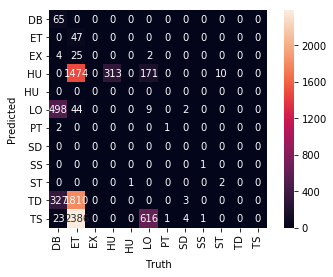

In [14]:
import matplotlib.pyplot as plt

labels = gnb_model.predict(test_X)
mat = confusion_matrix(test_Y, predicted_op)
sns.heatmap(mat,
            fmt='d',
            square=True,
            cbar=True,
            annot=True,
            xticklabels=le.classes_,
            yticklabels=le.classes_) # This should be distinct classes

#le.classes_
plt.xlabel('Truth'),
plt.ylabel('Predicted'),

### 4.3. Model Evaluation - classification_report  

In [13]:
# classification_report

# Here we need to give categorial value instead of label encoded value. It will be easy to interpretate
print("Naive Bayesconfusion_matrix :" ,classification_report(test_Y, predicted_op))


Naive Bayesconfusion_matrix :               precision    recall  f1-score   support

           0       0.07      1.00      0.13        65
           1       0.01      1.00      0.02        47
           2       0.00      0.00      0.00        31
           3       1.00      0.16      0.27      1968
           4       0.00      0.00      0.00         0
           5       0.01      0.02      0.01       553
           6       0.50      0.33      0.40         3
           7       0.00      0.00      0.00         0
           8       0.50      1.00      0.67         1
           9       0.17      0.67      0.27         3
          10       0.00      0.00      0.00      2140
          11       0.00      0.00      0.00      3031

   micro avg       0.06      0.06      0.06      7842
   macro avg       0.19      0.35      0.15      7842
weighted avg       0.25      0.06      0.07      7842



C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1145: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples.
  'recall', 'true', average, warn_for)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1145: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples.
  'recall', 'true', average, warn_for)
C:\Users\prabh\Anaconda3\lib\sit